#**Pós Inteligência Artificial - 2026**


**Disciplina**: Machine Learning

**Prof.**: Dr. Sirlon Diniz de Carvalho

**Aluno**: Flávio Lourenço da Silva

**Atividade Dataset**

1. Elabore um cenário que permita construir um dataset que contenha campos como Sexo, Idade, Renda, Profissão e Estado Civil etc. (opcionalmente o estudante pode escolher um dataset em que trabalha). Incluir saída esperada.

2. Definir o intervalo ou categorias aceitáveis para cada um dos campos (considere outliers)

3. Pesquisar sobre técnicas de normalização aplicáveis a cada caso

4. Implementar a normalização dos padrões para valores utilizando Python

Entregáveis esperados:
- Dataset bruto (formato csv)
- Dataset normalizado (formato csv)
- Algoritmo de normalização (comentado)
- Relatório do trabalho desenvolvido, justificando as transformações com base em literatura confiável (PDF)

## Imports necessários

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import numpy as np

## Buscando dados do Dataset People

In [100]:
# Carregar o dataset
url = 'https://raw.githubusercontent.com/flaviogyn/pos-ia-aplicada-ifg/main/repositories/machine_learning/dataset_people.csv'
df = pd.read_csv(url, encoding='latin1', sep=';')

# Tamanho dataset (linhas x colunas)
print(df.shape)

# Primeiras 5 primeiras linhas
df.head()


(2041, 6)


,SEXO,IDADE,RENDA,CODCBO,PROFISSAO,ESTADO_CIVIL
0,M,38,"1006,40",782305,MOTORISTA DE CARRO DE PASSEIO,SOLTEIRO(A)
1,M,44,"5004,67",313105,ELETROTECNICO,SEPARADO(A) JUDICIALMENTE
2,M,46,"1755,56",521105,VENDEDOR EM COMERCIO ATACADIST,SEPARADO(A) JUDICIALMENTE
3,M,34,"1981,77",411010,ASSISTENTE ADMINISTRATIVO,CASADO(A)
4,M,41,"1597,50",521105,VENDEDOR EM COMERCIO ATACADIST,OUTROS


## Análises Estátisticas Descritivas

In [101]:
# Exibir estatísticas descritivas para variáveis numéricas
df.describe()

,IDADE,CODCBO
count,2041.000000,2041.000000
mean,38.490936,483150.041646
std,10.824991,225907.343899
min,15.000000,0.000000
25%,31.000000,351605.000000
50%,38.000000,411010.000000
75%,45.000000,521105.000000
max,81.000000,992120.000000


In [102]:
# Exibir estatísticas descritivas para variáveis categóricas
df.describe(include=['O'])

,SEXO,RENDA,PROFISSAO,ESTADO_CIVIL
count,2041,2041,2041,2041
unique,2,1525,96,6
top,M,"900,00",VENDEDOR EM COMERCIO ATACADIST,SOLTEIRO(A)
freq,1585,48,309,1059


In [103]:
# Moda
df.mode()

,SEXO,IDADE,RENDA,CODCBO,PROFISSAO,ESTADO_CIVIL
0,M,37,"900,00",521105,VENDEDOR EM COMERCIO ATACADIST,SOLTEIRO(A)


## Limpeza dos dados

In [104]:
# Exibir informações iniciais para identificar dados faltantes e tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2041 entries, 0 to 2040
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   SEXO          2041 non-null   object
 1   IDADE         2041 non-null   int64 
 2   RENDA         2041 non-null   object
 3   CODCBO        2041 non-null   int64 
 4   PROFISSAO     2041 non-null   object
 5   ESTADO_CIVIL  2041 non-null   object
dtypes: int64(2), object(4)
memory usage: 95.8+ KB


In [105]:
# Verifica a existencia de valores vazios
df.isnull().sum()

,0
SEXO,0
IDADE,0
RENDA,0
CODCBO,0
PROFISSAO,0
ESTADO_CIVIL,0


In [106]:
# Transforma os dados da coluna RENDA para decimais
df['RENDA'] = df['RENDA'].str.replace(',', '.').astype(float)
df.head()

,SEXO,IDADE,RENDA,CODCBO,PROFISSAO,ESTADO_CIVIL
0,M,38,1006.40,782305,MOTORISTA DE CARRO DE PASSEIO,SOLTEIRO(A)
1,M,44,5004.67,313105,ELETROTECNICO,SEPARADO(A) JUDICIALMENTE
2,M,46,1755.56,521105,VENDEDOR EM COMERCIO ATACADIST,SEPARADO(A) JUDICIALMENTE
3,M,34,1981.77,411010,ASSISTENTE ADMINISTRATIVO,CASADO(A)
4,M,41,1597.50,521105,VENDEDOR EM COMERCIO ATACADIST,OUTROS


## Criando a coluna de Saída Esperada (Perfil Consumidor)

In [107]:
def classificar_perfil(row):
    if row["RENDA"] > 10000:
        return "A"
    elif row["RENDA"] > 3000:
        return "B"
    else:
        return "C"

df['PERFIL_CONSUMIDOR'] = df.apply(classificar_perfil, axis=1)
df.head()

,SEXO,IDADE,RENDA,CODCBO,PROFISSAO,ESTADO_CIVIL,PERFIL_CONSUMIDOR
0,M,38,1006.40,782305,MOTORISTA DE CARRO DE PASSEIO,SOLTEIRO(A),C
1,M,44,5004.67,313105,ELETROTECNICO,SEPARADO(A) JUDICIALMENTE,B
2,M,46,1755.56,521105,VENDEDOR EM COMERCIO ATACADIST,SEPARADO(A) JUDICIALMENTE,C
3,M,34,1981.77,411010,ASSISTENTE ADMINISTRATIVO,CASADO(A),C
4,M,41,1597.50,521105,VENDEDOR EM COMERCIO ATACADIST,OUTROS,C


## Normalização dos dados

### Transformando as váriaveis categóricas nominais em ordinais

In [108]:
# Sexo
print("\nSexo Antes", df['SEXO'].unique());


Sexo Antes ['M' 'F']


In [109]:
# Transforma em números
df['SEXO'] = df['SEXO'].replace({'M': 0, 'F': 1});
df['SEXO'].head()

/tmp/ipykernel_11567/1401241163.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['SEXO'] = df['SEXO'].replace({'M': 0, 'F': 1});


,SEXO
0,0
1,0
2,0
3,0
4,0


In [110]:
# Perfil do Consumidor
print("\nPerfil do Consumidor", df['PERFIL_CONSUMIDOR'].unique());


Perfil do Consumidor ['C' 'B' 'A']


In [111]:
# One-Hot Encoding
# O método transformará a coluna original em 3 colunas separadas.
# Para Perfil Consumidor A, a coluna "PERFIL_CONSUMIDOR" recebe (1) e as outras colunas recebem (0).

# Aplicar One-Hot
df = pd.get_dummies(df, columns=['PERFIL_CONSUMIDOR'], dtype=int)

print('\nDataFrame após One-Hot Encoding do PERFIL_CONSUMIDOR:')
df.head()


DataFrame após One-Hot Encoding do PERFIL_CONSUMIDOR:


,SEXO,IDADE,RENDA,CODCBO,PROFISSAO,ESTADO_CIVIL,PERFIL_CONSUMIDOR_A,PERFIL_CONSUMIDOR_B,PERFIL_CONSUMIDOR_C
0,0,38,1006.40,782305,MOTORISTA DE CARRO DE PASSEIO,SOLTEIRO(A),0,0,1
1,0,44,5004.67,313105,ELETROTECNICO,SEPARADO(A) JUDICIALMENTE,0,1,0
2,0,46,1755.56,521105,VENDEDOR EM COMERCIO ATACADIST,SEPARADO(A) JUDICIALMENTE,0,0,1
3,0,34,1981.77,411010,ASSISTENTE ADMINISTRATIVO,CASADO(A),0,0,1
4,0,41,1597.50,521105,VENDEDOR EM COMERCIO ATACADIST,OUTROS,0,0,1


In [112]:
# Estado Civil
Estado_Civil = df['ESTADO_CIVIL'].unique()

print(f"\nNúmero de estados civis únicos: {len(Estado_Civil)}")
print("\nEstado Civil Antes", Estado_Civil);


Número de estados civis únicos: 6

Estado Civil Antes ['SOLTEIRO(A)' 'SEPARADO(A) JUDICIALMENTE' 'CASADO(A)' 'OUTROS'
 'DESQUITADO(A)' 'DIVORCIADO(A)']


In [113]:
# One-Hot Encoding
# O método transformará a coluna original em 6 colunas separadas.
# Para uma pessoa Casada, a coluna "CASADO(A)" recebe (1) e as outras colunas recebem (0).

# Aplicar One-Hot
df = pd.get_dummies(df, columns=['ESTADO_CIVIL'], dtype=int)

print('\nDataFrame após One-Hot Encoding do ESTADO_CIVIL:')
df.head()


DataFrame após One-Hot Encoding do ESTADO_CIVIL:


,SEXO,IDADE,RENDA,CODCBO,PROFISSAO,PERFIL_CONSUMIDOR_A,PERFIL_CONSUMIDOR_B,PERFIL_CONSUMIDOR_C,ESTADO_CIVIL_CASADO(A),ESTADO_CIVIL_DESQUITADO(A),ESTADO_CIVIL_DIVORCIADO(A),ESTADO_CIVIL_OUTROS,ESTADO_CIVIL_SEPARADO(A) JUDICIALMENTE,ESTADO_CIVIL_SOLTEIRO(A)
0,0,38,1006.40,782305,MOTORISTA DE CARRO DE PASSEIO,0,0,1,0,0,0,0,0,1
1,0,44,5004.67,313105,ELETROTECNICO,0,1,0,0,0,0,0,1,0
2,0,46,1755.56,521105,VENDEDOR EM COMERCIO ATACADIST,0,0,1,0,0,0,0,1,0
3,0,34,1981.77,411010,ASSISTENTE ADMINISTRATIVO,0,0,1,1,0,0,0,0,0
4,0,41,1597.50,521105,VENDEDOR EM COMERCIO ATACADIST,0,0,1,0,0,0,1,0,0


In [114]:
# Profissão
Profissao = df['PROFISSAO'].unique()

print(f"\nNúmero de Profissões únicos: {len(Profissao)}")
print("\nProfissão Antes", Profissao);


Número de Profissões únicos: 96

Profissão Antes ['MOTORISTA DE CARRO DE PASSEIO' 'ELETROTECNICO'
 'VENDEDOR EM COMERCIO ATACADIST' 'ASSISTENTE ADMINISTRATIVO'
 'GERENTE DE COMPRAS' 'AGENTE PUBLICITARIO'
 'GERENTE DE PROJETOS E SERVICOS DE MANUTE'
 'AUXILIAR DE MANUTENCAO PREDIAL' 'GERENTE DE PROJ DE TEC DA INFORMAÇÃO'
 'AUXILIAR DE ESCRITORIO, EM GER' 'MECANICO DE VEICULOS AUTOMOTOR'
 'MOTORISTA DE CAMINHAO' 'GERENTE COMERCIAL' 'COMPRADOR'
 'ELETRICISTA DE MANUTENCAO, GER' 'RECEPCIONISTA, EM GERAL'
 'GERENTE DE VENDAS' 'SUPERVISOR DE VENDAS COMERCIAL' 'SEM CBO'
 'DIRETOR DE OPERACOES COMERCIAI' 'EMPREGADO DOMESTICO'
 'OPERADOR DE EMPILHADEIRA' 'SUPERVISOR DA MANUTENÇÃO E REPARAÇ'
 'ANALISTA DE SISTEMA' 'DESENHISTA PROJETISTA DE ELETR'
 'MOTORISTA OPER DE GUINCHO' 'CONTADOR' 'GERENTE DE PROD E OP AGROPECUA'
 'ANALISTA DE NEGOCIOS' 'ADVOGADO DE EMPRESA'
 'MECANICO DE MANUTENÇÃO DE MAQUINAS, EM GERAL'
 'ANALISTA DE GESTÃO DE ESTOQUE' 'ALMOXARIFE'
 'ANALISTA DE RECURSOS HUMANOS' 'PORTEIR

In [115]:
# Descartar a coluna PROFISSAO
# Mantemos a coluna CODCBO para a extração hierárquica
if 'PROFISSAO' in df.columns:
    df = df.drop(columns=['PROFISSAO'])

In [116]:
# Garante que CBO seja string com 6 dígitos (com zero-fill se necessário)
df['CODCBO'] = df['CODCBO'].astype(str).str.zfill(6)

# Extração hierárquica CBO do Ministério da Saúde
# Fonte no link http://www.mtecbo.gov.br/cbosite/pages/downloads.jsf
df['GRANDE_GRUPO']      = df['CODCBO'].str[:1].astype(int)  # 9 categorias
df['SUBGRUPO_PRINC']    = df['CODCBO'].str[:2].astype(int)  # ~47 categorias  ← sua "SubGrupo do Principal"
df['SUBGRUPO']          = df['CODCBO'].str[:3].astype(int)  # ~192 categorias ← sua "SubGrupo"
df['FAMILIA']           = df['CODCBO'].str[:4].astype(int)  # ~595 famílias

df.head()

,SEXO,IDADE,RENDA,CODCBO,PERFIL_CONSUMIDOR_A,PERFIL_CONSUMIDOR_B,PERFIL_CONSUMIDOR_C,ESTADO_CIVIL_CASADO(A),ESTADO_CIVIL_DESQUITADO(A),ESTADO_CIVIL_DIVORCIADO(A),ESTADO_CIVIL_OUTROS,ESTADO_CIVIL_SEPARADO(A) JUDICIALMENTE,ESTADO_CIVIL_SOLTEIRO(A),GRANDE_GRUPO,SUBGRUPO_PRINC,SUBGRUPO,FAMILIA
0,0,38,1006.40,782305,0,0,1,0,0,0,0,0,1,7,78,782,7823
1,0,44,5004.67,313105,0,1,0,0,0,0,0,1,0,3,31,313,3131
2,0,46,1755.56,521105,0,0,1,0,0,0,0,1,0,5,52,521,5211
3,0,34,1981.77,411010,0,0,1,1,0,0,0,0,0,4,41,411,4110
4,0,41,1597.50,521105,0,0,1,0,0,0,1,0,0,5,52,521,5211


In [117]:
# Escolher a coluna GRANDE_GRUPO pois CBO possui semântica ocupacional real
# Tabela do CBO do MTB
'''
CODIGO; TITULO
0; MEMBROS DAS FORÇAS ARMADAS, POLICIAIS E BOMBEIROS MILITARES
1; MEMBROS SUPERIORES DO PODER PÚBLICO, DIRIGENTES DE ORGANIZAÇÕES DE INTERESSE PÚBLICO E DE EMPRESAS, GERENTES
2; PROFISSIONAIS DAS CIÊNCIAS E DAS ARTES
3; TÉCNICOS DE NIVEL MÉDIO
4; TRABALHADORES DE SERVIÇOS ADMINISTRATIVOS
5; TRABALHADORES DOS SERVIÇOS, VENDEDORES DO COMÉRCIO EM LOJAS E MERCADOS
6; TRABALHADORES AGROPECUÁRIOS, FLORESTAIS E DA PESCA
7; TRABALHADORES DA PRODUÇÃO DE BENS E SERVIÇOS INDUSTRIAIS
8; TRABALHADORES DA PRODUÇÃO DE BENS E SERVIÇOS INDUSTRIAIS
9; TRABALHADORES EM SERVIÇOS DE REPARAÇÃO E MANUTENÇÃO

'''

'\nCODIGO; TITULO\n0; MEMBROS DAS FORÇAS ARMADAS, POLICIAIS E BOMBEIROS MILITARES                                                                       \n1; MEMBROS SUPERIORES DO PODER PÚBLICO, DIRIGENTES DE ORGANIZAÇÕES DE INTERESSE PÚBLICO E DE EMPRESAS, GERENTES                      \n2; PROFISSIONAIS DAS CIÊNCIAS E DAS ARTES                                                                                            \n3; TÉCNICOS DE NIVEL MÉDIO                                                                                                           \n4; TRABALHADORES DE SERVIÇOS ADMINISTRATIVOS                                                                                         \n5; TRABALHADORES DOS SERVIÇOS, VENDEDORES DO COMÉRCIO EM LOJAS E MERCADOS                                                            \n6; TRABALHADORES AGROPECUÁRIOS, FLORESTAIS E DA PESCA                                                                                \n7; TRABALHADORES DA PRODUÇÃO DE BENS

In [118]:
# Descartar a colunas que não serão mais necessárias para o Modelo

if 'CODCBO' in df.columns:
    df = df.drop(columns=['CODCBO'])

if 'SUBGRUPO_PRINC' in df.columns:
    df = df.drop(columns=['SUBGRUPO_PRINC'])

if 'SUBGRUPO' in df.columns:
    df = df.drop(columns=['SUBGRUPO'])

if 'FAMILIA' in df.columns:
    df = df.drop(columns=['FAMILIA'])

df.head()

,SEXO,IDADE,RENDA,PERFIL_CONSUMIDOR_A,PERFIL_CONSUMIDOR_B,PERFIL_CONSUMIDOR_C,ESTADO_CIVIL_CASADO(A),ESTADO_CIVIL_DESQUITADO(A),ESTADO_CIVIL_DIVORCIADO(A),ESTADO_CIVIL_OUTROS,ESTADO_CIVIL_SEPARADO(A) JUDICIALMENTE,ESTADO_CIVIL_SOLTEIRO(A),GRANDE_GRUPO
0,0,38,1006.40,0,0,1,0,0,0,0,0,1,7
1,0,44,5004.67,0,1,0,0,0,0,0,1,0,3
2,0,46,1755.56,0,0,1,0,0,0,0,1,0,5
3,0,34,1981.77,0,0,1,1,0,0,0,0,0,4
4,0,41,1597.50,0,0,1,0,0,0,1,0,0,5


In [119]:
# One-Hot Encoding
# O método transformará a coluna original em 6 colunas separadas.
# Para uma pessoa Casada, a coluna "AREA_CBO_A" recebe (1) e as outras colunas recebem (0).

# Renomea a coluna GRANDE_GRUPO
df = df.rename(columns={'GRANDE_GRUPO': 'AREA_CBO'})

# Aplicar One-Hot
df = pd.get_dummies(df, columns=['AREA_CBO'], dtype=int)

print('\nDataFrame após One-Hot Encoding do AREA_CBO:')
df.head()


DataFrame após One-Hot Encoding do AREA_CBO:


,SEXO,IDADE,RENDA,PERFIL_CONSUMIDOR_A,PERFIL_CONSUMIDOR_B,PERFIL_CONSUMIDOR_C,ESTADO_CIVIL_CASADO(A),ESTADO_CIVIL_DESQUITADO(A),ESTADO_CIVIL_DIVORCIADO(A),ESTADO_CIVIL_OUTROS,...,AREA_CBO_0,AREA_CBO_1,AREA_CBO_2,AREA_CBO_3,AREA_CBO_4,AREA_CBO_5,AREA_CBO_6,AREA_CBO_7,AREA_CBO_8,AREA_CBO_9
0,0,38,1006.40,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,44,5004.67,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,0,46,1755.56,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,34,1981.77,0,0,1,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,41,1597.50,0,0,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0


## Analisando a distribuição dos dados

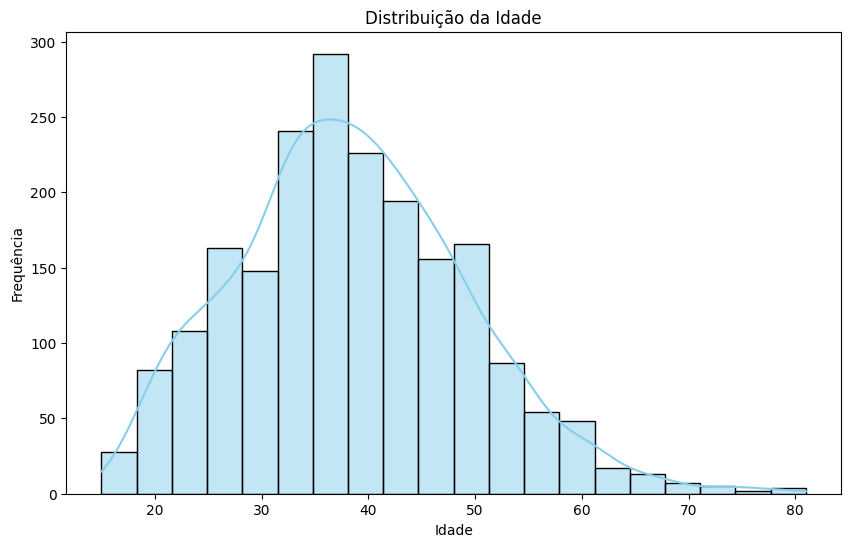

In [120]:
# Olhando distribuição dos dados
plt.figure(figsize=(10, 6))
sns.histplot(df, x='IDADE', bins=20, color="skyblue", kde=True, stat="count");
plt.title('Distribuição da Idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

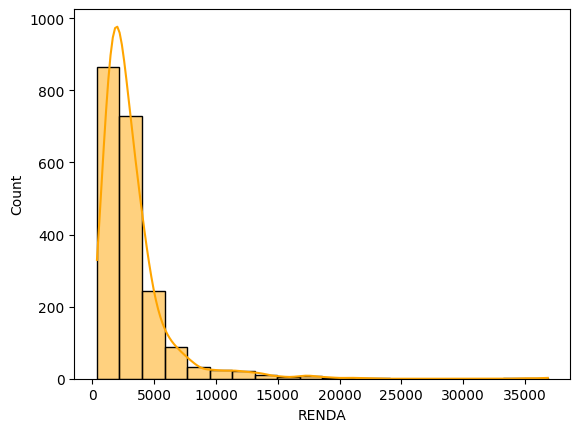

In [121]:
# Olhando distribuição dos dados
sns.histplot(df, x='RENDA', bins=20, color="orange", kde=True, stat="count");

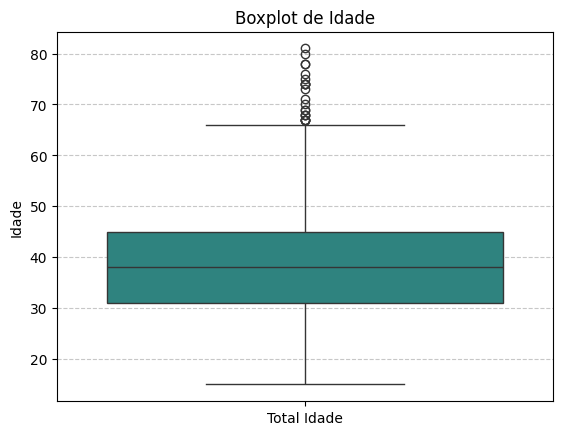

In [122]:
# Idade
df_plot = df.copy()
df_plot['Category'] = 'Total Idade'

sns.boxplot(x='Category', y='IDADE', data=df_plot, palette='viridis', hue='Category', legend=False)
plt.title('Boxplot de Idade')
plt.xlabel('')
plt.ylabel('Idade')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Análise de Outliers

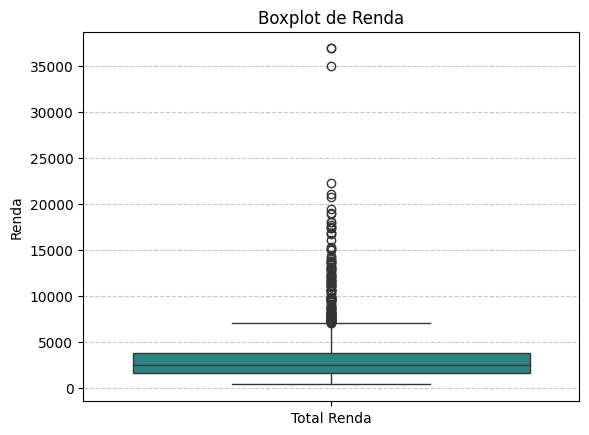

In [123]:
# Renda
df_plot = df.copy()
df_plot['Category'] = 'Total Renda'

sns.boxplot(x='Category', y='RENDA', data=df_plot, palette='viridis', hue='Category', legend=False)
plt.title('Boxplot de Renda')
plt.xlabel('')
plt.ylabel('Renda')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

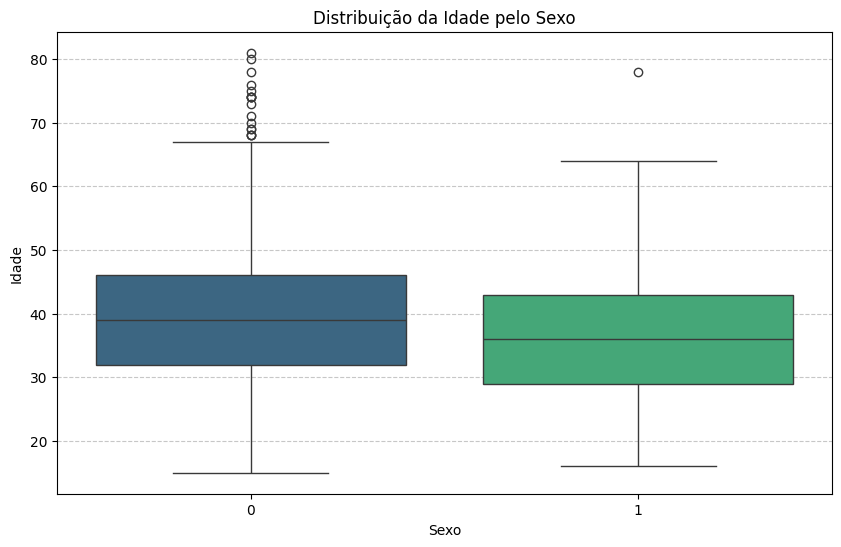

In [124]:
# Idade x Sexo
plt.figure(figsize=(10, 6))
sns.boxplot(x='SEXO', y='IDADE', data=df, palette='viridis', hue='SEXO', legend=False)
plt.title('Distribuição da Idade pelo Sexo')
plt.xlabel('Sexo')
plt.ylabel('Idade')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Aplicando Técnicas de Normalização

In [125]:
# IDADE
# Distribuição normalmente próxima da normal.

# Usando o methodo StandardScaler que Transforma para:
# média = 0
# desvio padrão = 1

scaler = StandardScaler()

print(f"\n[Min-Max] idade")
print(f"  antes : min={df['IDADE'].min()}, max={df['IDADE'].max()}")

# ── Min-Max: idade ──
df['IDADE'] = scaler.fit_transform(df[['IDADE']])

print(f"  depois: min={df['IDADE'].min()}, max={df['IDADE'].max()}")



[Min-Max] idade
  antes : min=15, max=81
  depois: min=-2.1705969507459866, max=3.9278999279105755


In [126]:
# RENDA
# Normalmente possui forte assimetria.
# df['RENDA'] = np.log1p(df['RENDA'])

# Usando RobustScaler
# Ideal quando existem muitos outliers.
df['RENDA'] = scaler.fit_transform(df[['RENDA']])

mediana = df["RENDA"].median()
iqr     = df["RENDA"].quantile(0.75) - df["RENDA"].quantile(0.25)
print(f"\n[Robust Scaler] renda")
print(f"  mediana={mediana:.0f}, IQR={iqr:.0f}")
print(f"  range normalizado: [{df['RENDA'].min():.2f}, {df['RENDA'].max():.2f}]")



[Robust Scaler] renda
  mediana=-0, IQR=1
  range normalizado: [-0.97, 11.53]


# Análise de Correlações e Proporções

Nesta seção, faremos uma análise do *dataset* da Produção Ambulatorial do Estado do Acre. Esta análise pode nos revelar relações importantes entre as variáveis numéricas do *dataset*, podendo nos dar vários *insights* sobre sua relação e ajudar no planejamento e decisões técnicas.

<Axes: >

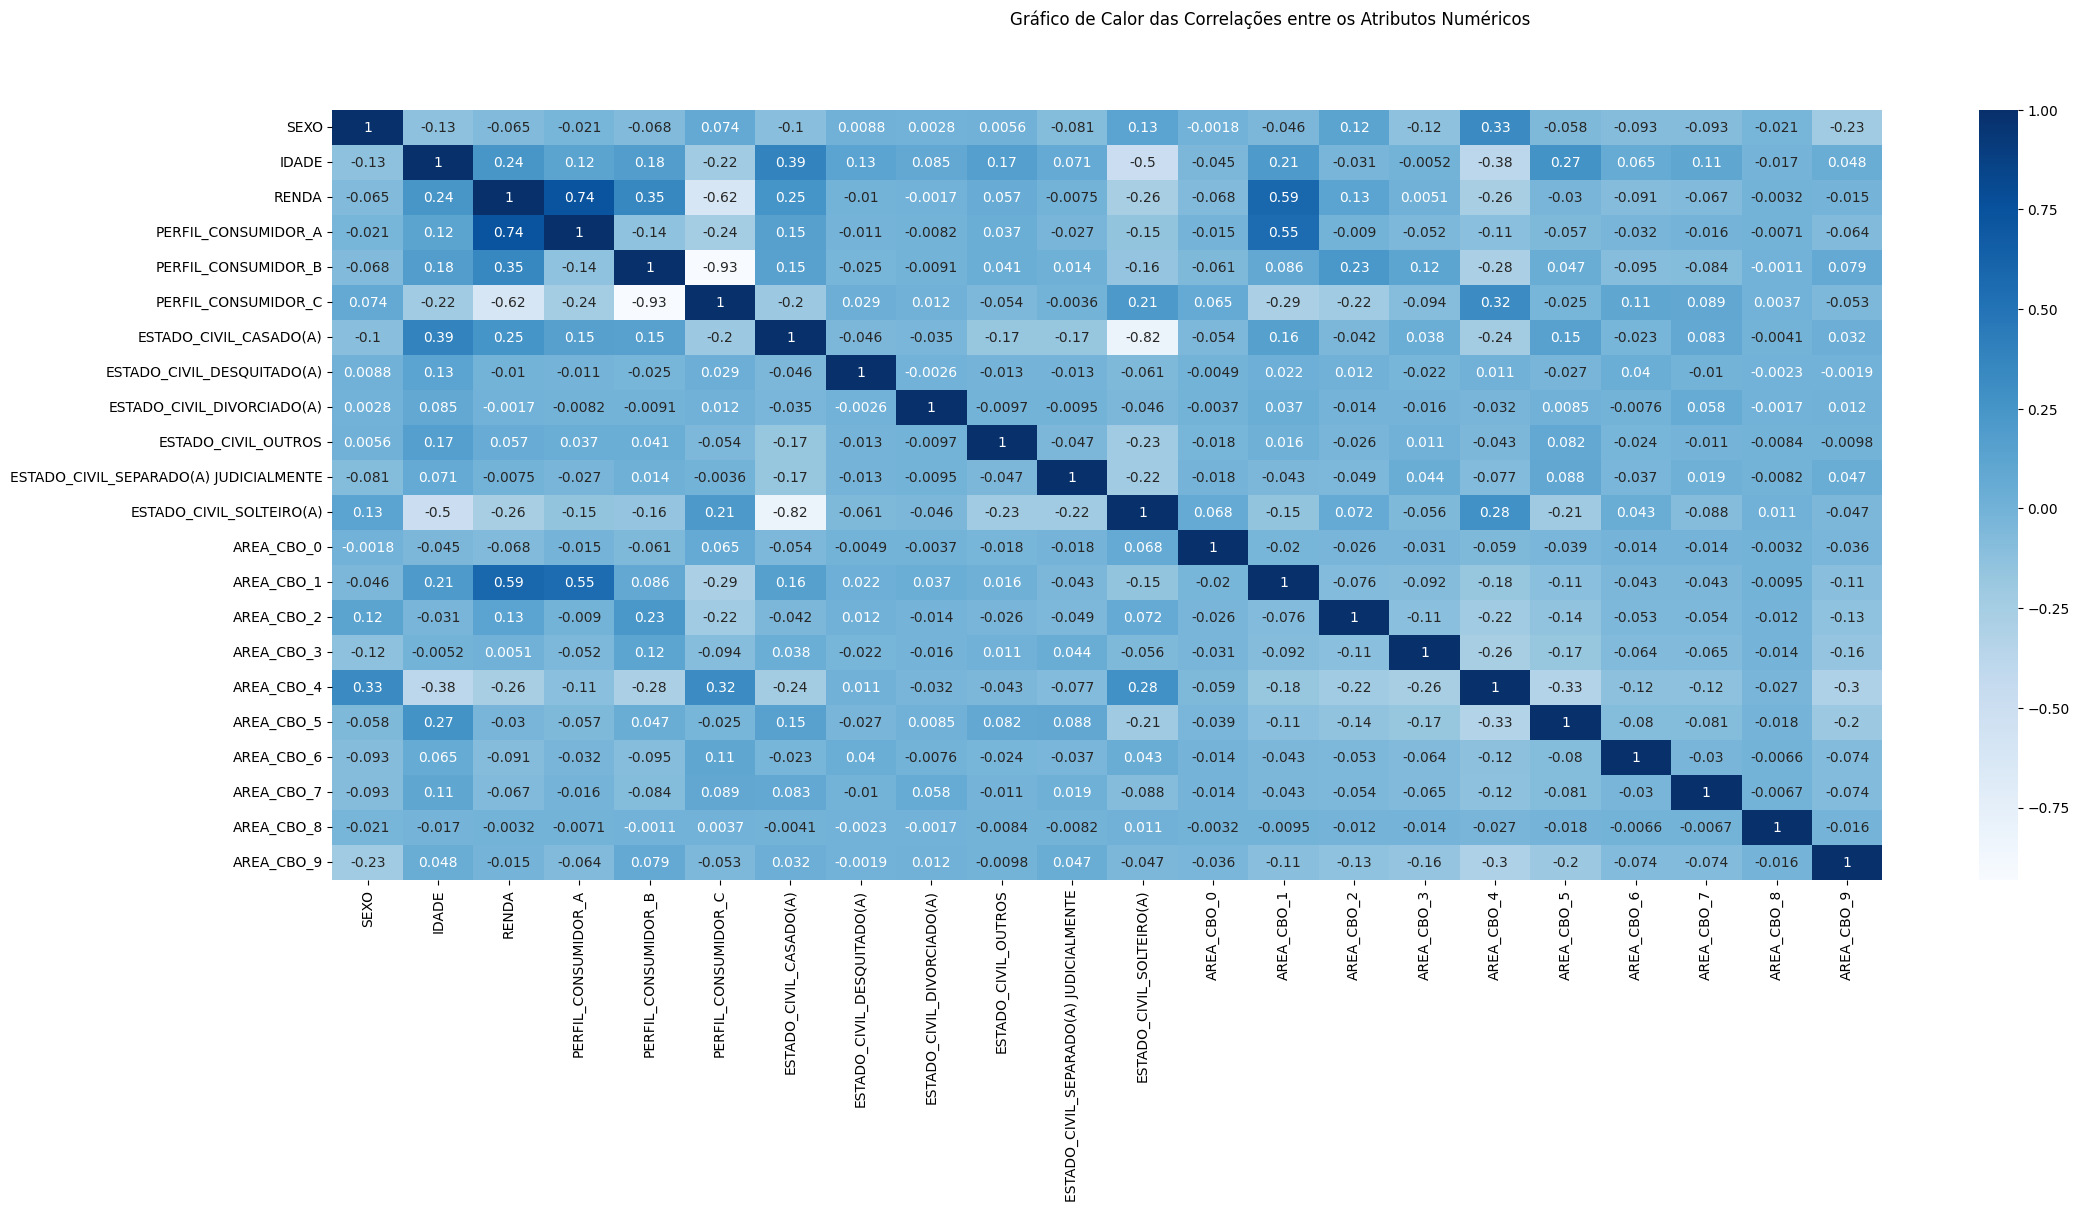

In [127]:
# Somente atributos numéricos são considerados
plt.figure(figsize=(25, 10))
plt.suptitle("Gráfico de Calor das Correlações entre os Atributos Numéricos")
numericos = df.select_dtypes(include=['int', 'float', 'bool'])
sns.heatmap(numericos.corr(), annot=True, cmap='Blues')

# Salvando (Exportando) o DataFrame tratado

In [128]:
df.to_csv('dataset_people_tratato.csv', encoding='latin1', sep=';', index=False)

# Conclusão feito pela própria IA

# Relatório: Transformações e Normalização de Dados para Machine Learning

## 1. Introdução

Este relatório detalha as etapas de pré-processamento e transformação de um conjunto de dados (`dataset_people.csv`) com o objetivo de prepará-lo para aplicações de Machine Learning. O processo envolveu limpeza de dados, engenharia de atributos e normalização de variáveis, com justificativas baseadas em princípios fundamentais da ciência de dados. O dataset contém informações demográficas e profissionais, como Sexo, Idade, Renda, Profissão (CBO) e Estado Civil, e a saída esperada é a categorização do `PERFIL_CONSUMIDOR`.

## 2. Descrição do Dataset Original

O dataset inicial possui `2041` entradas e `6` colunas:
- `SEXO`: Categórica (M/F)
- `IDADE`: Numérica (int64)
- `RENDA`: Numérica (object/string com vírgulas como decimais)
- `CODCBO`: Numérica (int64), representando o Código Brasileiro de Ocupações
- `PROFISSAO`: Categórica (texto livre)
- `ESTADO_CIVIL`: Categórica (múltiplas categorias)

### 2.1 Análise Estatística Descritiva Inicial

A análise descritiva inicial (`df.describe()`, `df.info()`, `df.isnull().sum()`) revelou a necessidade de tratamento da coluna `RENDA` (como `object` e com separador decimal inadequado) e a presença de múltiplas categorias nas colunas `PROFISSAO` e `ESTADO_CIVIL`. Não foram encontrados valores nulos explícitos.

## 3. Limpeza e Transformação dos Dados

### 3.1 Tratamento da Coluna `RENDA`

*   **Problema**: A coluna `RENDA` foi carregada como tipo `object` (string) e utilizava vírgula (`,`) como separador decimal, impedindo operações numéricas.
*   **Transformação**: A vírgula foi substituída por ponto (`.`), e a coluna foi convertida para o tipo `float`.
*   **Justificativa**: A conversão para um tipo numérico (`float`) é essencial para que a renda possa ser utilizada em cálculos matemáticos, comparações e algoritmos de Machine Learning. A padronização do separador decimal é uma prática comum para garantir a integridade dos dados numéricos (Ref. *Pedregosa et al., 2011 - Scikit-learn: Machine Learning in Python*).

### 3.2 Criação da Coluna `PERFIL_CONSUMIDOR`

*   **Problema**: O objetivo é classificar os indivíduos em perfis de consumidor com base na renda.
*   **Transformação**: Foi definida uma função `classificar_perfil` que atribui um perfil (A, B ou C) com base em faixas de renda: `> 10000` (A), `> 3000` (B), `<= 3000` (C). Essa função foi aplicada ao DataFrame para criar a coluna `PERFIL_CONSUMIDOR`.
*   **Justificativa**: A engenharia de atributos, como a criação de variáveis categóricas a partir de variáveis contínuas (binarização ou discretização), é uma técnica comum para simplificar o modelo, introduzir conhecimento de domínio e atender aos requisitos de algoritmos de classificação (Ref. *Kuhn & Johnson, 2013 - Applied Predictive Modeling*).

### 3.3 Normalização de Variáveis Categóricas

#### 3.3.1 `SEXO`

*   **Problema**: Variável categórica nominal ('M', 'F').
*   **Transformação**: Convertida para representação numérica binária: 'M' para `0` e 'F' para `1`.
*   **Justificativa**: A maioria dos algoritmos de Machine Learning exige entradas numéricas. A codificação binária é simples e eficaz para variáveis categóricas com apenas duas classes, evitando o aumento desnecessário da dimensionalidade (Ref. *Géron, 2019 - Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*).

#### 3.3.2 `PERFIL_CONSUMIDOR` e `ESTADO_CIVIL`

*   **Problema**: Variáveis categóricas nominais com mais de duas classes, sem ordem intrínseca.
*   **Transformação**: Aplicado *One-Hot Encoding*. Cada categoria única de `PERFIL_CONSUMIDOR` (A, B, C) e `ESTADO_CIVIL` foi transformada em uma nova coluna binária. Por exemplo, `PERFIL_CONSUMIDOR_A`, `PERFIL_CONSUMIDOR_B`, `PERFIL_CONSUMIDOR_C`.
*   **Justificativa**: *One-Hot Encoding* é a técnica preferida para variáveis categóricas nominais em que a ordem entre as categorias não é significativa. Ele evita que o modelo atribua uma relação ordinal (e.g., que 'A' é 'maior' que 'B') que não existe nos dados, representando cada categoria como um vetor binário esparso (Ref. *Aggarwal, 2015 - Data Mining: The Textbook*).

#### 3.3.3 Tratamento da Variável Ocupacional (`PROFISSAO` / `CODCBO`)

*   **Problema**: A coluna `PROFISSAO` continha descrições de texto livre, o que dificulta o processamento por modelos de ML. A coluna `CODCBO` era um código numérico hierárquico.
*   **Transformação**:
    1.  A coluna `PROFISSAO` foi descartada.
    2.  A coluna `CODCBO` foi garantida como `string` com preenchimento de zeros (`zfill(6)`) para manter a consistência.
    3.  Foram extraídas as hierarquias do CBO (`GRANDE_GRUPO`, `SUBGRUPO_PRINC`, `SUBGRUPO`, `FAMILIA`) com base na estrutura de 6 dígitos do código.
    4.  A coluna `GRANDE_GRUPO` foi renomeada para `AREA_CBO`.
    5.  A coluna `AREA_CBO` foi submetida a *One-Hot Encoding*.
    6.  As colunas `CODCBO`, `SUBGRUPO_PRINC`, `SUBGRUPO` e `FAMILIA` foram descartadas após a extração e codificação do `GRANDE_GRUPO`.
*   **Justificativa**: A substituição de descrições textuais por um sistema de codificação padronizado como o CBO (Código Brasileiro de Ocupações) é uma forma robusta de transformar dados qualitativos em quantitativos. A extração hierárquica e o *One-Hot Encoding* do `GRANDE_GRUPO` permitem que o modelo capture as características gerais da ocupação sem introduzir alta dimensionalidade excessiva ou a complexidade de processar o texto livre. Focar no `GRANDE_GRUPO` (ou `AREA_CBO`) é uma decisão de engenharia de atributos que equilibra granularidade e interpretabilidade para o modelo. (Ref. *Domingos, 2012 - The Master Algorithm*).

## 4. Análise e Visualização da Distribuição dos Dados e Outliers

Após as transformações, foram realizadas análises visuais para entender as distribuições das variáveis numéricas e identificar outliers:

*   **Histogramas (`IDADE`, `RENDA`)**: Utilizados para visualizar a forma da distribuição das variáveis contínuas, identificando assimetrias e a presença de múltiplos picos.
*   **Boxplots (`IDADE`, `RENDA`)**: Empregados para detectar e visualizar a presença de *outliers*. Um boxplot mostra a mediana, quartis e pontos que se estendem além dos 'bigodes', indicando valores que estão a uma distância significativa da maioria dos dados.
*   **Boxplot `IDADE` por `SEXO`**: Ajuda a comparar a distribuição da idade entre os gêneros, verificando se há diferenças significativas ou padrões específicos de outliers em cada grupo.

**Justificativa**: A Análise Exploratória de Dados (EDA) e a visualização são etapas críticas no pré-processamento. Elas fornecem insights sobre a qualidade dos dados, a presença de anomalias (outliers) e as distribuições das variáveis, informando decisões sobre transformações adicionais ou estratégias de modelagem (Ref. *Tukey, 1977 - Exploratory Data Analysis*).

## 5. Salvar o Dataset Tratado

*   **Transformação**: O DataFrame resultante, com todas as transformações aplicadas, foi salvo como `dataset_people_tratato.csv`.
*   **Justificativa**: A persistência do dataset tratado garante que o trabalho de pré-processamento não precise ser refeito e que os dados prontos para modelagem possam ser acessados de forma eficiente em etapas futuras do pipeline de Machine Learning.

## 6. Conclusão

As transformações realizadas neste notebook, incluindo a limpeza da coluna `RENDA`, a criação do `PERFIL_CONSUMIDOR`, a codificação *One-Hot* para variáveis categóricas e a engenharia de atributos a partir do `CODCBO`, foram cruciais para preparar o dataset. Essas etapas não apenas padronizam os dados, mas também os tornam mais adequados para serem consumidos por algoritmos de Machine Learning, potencialmente melhorando o desempenho e a interpretabilidade dos modelos.

## Referências

*   Aggarwal, C. C. (2015). *Data Mining: The Textbook*. Springer.
*   Domingos, P. (2012). *The Master Algorithm: How the Quest for the Ultimate Learning Machine Will Remake Our World*. Basic Books.
*   Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems* (2nd ed.). O'Reilly Media.
*   Kuhn, M., & Johnson, K. (2013). *Applied Predictive Modeling*. Springer.
*   Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, E. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.
*   Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.

---